# **15 · Crosswalk 정합성 자동검증 — 매핑 문서가 아니라 데이터가 매핑을 증명한다**

### **"개념→변수 crosswalk(인구 10종 · 신뢰 배터리 6종 · 매체 8+3종)의 '어느 해에 존재해야 하는가'를 기대 패턴 상수로 박고, 결합 패널의 presence 행렬과 전 셀 대조 — 기대된 부재만 부재이고, 기대 밖 구멍은 0건이다"**

> KPF 「언론 통계 분석·활용 경진대회」 · 대상 = `harmonize.SRC`·`CRED_BATTERY`·`USE_BATTERY`·`USE_NEW_MEDIA` 매핑 전체 · 방법 = **기대 가용성 패턴 ↔ 실측 presence 전 셀 대조**

> 📍 **파이프라인 위치**: 5단계 표준 흐름 中 **② 데이터 전처리(매핑 게이트)** · CRISP-DM **P3** · [전체 지도](README.md)

## **연구 질문 (이 노트북이 답하는 것)**

> **Q1.** crosswalk 매핑(target 27종 × 7개년)은 **빠짐도 남음도 없이** 구현됐는가 — 매핑 선언과 패널 실측이 전 셀에서 일치하는가?
> **Q2.** '구조적 부재'로 선언된 칸(2019 신뢰 3종, 2023+ trustworthy 등)은 **정확히 그 칸만** 비어 있는가 — 기대 밖 구멍(구현 버그의 지문)은 없는가?
> **Q3.** 유효응답 규모는 변수·연도별로 분석에 충분한가 — 어느 변수가 어느 분석의 병목인가?

## **이 노트북의 위상**

`10` §4~5가 crosswalk의 *설계*(원문항 존재)를 보였고 `11`이 *구현*(결합)을 했다면, 15는 그 사이의 계약을 **자동 게이트**로 만든다: 매핑 상수(SSOT)에서 기대 패턴을 도출하고, 패널의 presence 행렬과 전 셀 대조한다. 문서와 코드가 어긋나는 순간 이 노트북이 먼저 부러진다 — crosswalk 개정 시 재실행이 곧 회귀 테스트다.

- **로직 SSOT(thin import)**: `harmonize.SRC`·`CRED_BATTERY`·`USE_BATTERY`·`USE_NEW_MEDIA`(매핑 선언) + `harmonize.presence_matrix`(실측).
- **명세 문서**: `docs/design/variable-crosswalk.md` v0.3(§3·§3.4-bis·§5).

## **목차**

| § | 내용 | 산출 |
|---|------|------|
| 1 | [전제] 매핑 검증을 왜 자동 게이트로 — **Decision Box ①** | — |
| 2 | [실행] 매핑 선언 → 기대 가용성 패턴 도출 | 기대표 |
| 3 | [실행] 패널 presence 실측 ↔ 기대 전 셀 대조 + [시각화] | 대조 히트맵 |
| 4 | [발견] 유효응답 규모 — 분석별 병목 지도 | 규모표 |
| 5 | [입증] 검증 셀 — 전 셀 assert | PASS |
| 6 | 종합 | — |

In [1]:
import sys
from pathlib import Path
import numpy as np, pandas as pd

ROOT = Path.cwd()
while not (ROOT / "src" / "harmonize.py").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

import harmonize as hz

get_ipython().run_line_magic("matplotlib", "inline")
import matplotlib.pyplot as plt
from matplotlib import font_manager
for _nm in ["Malgun Gothic", "맑은 고딕", "NanumGothic", "Gulim"]:
    try:
        font_manager.findfont(_nm, fallback_to_default=False)
        plt.rcParams["font.family"] = _nm; break
    except Exception: continue
plt.rcParams["axes.unicode_minus"] = False

panel = pd.read_parquet(hz.OUT_PARQUET)
assert len(panel) == 90996
n_targets = len(hz.SRC) + len(hz.CRED_BATTERY) + len(hz.USE_BATTERY) + len(hz.USE_NEW_MEDIA)
print(f"패널 {len(panel):,}행 · 매핑 선언 {n_targets}종 × {len(hz.YEARS)}개년 = {n_targets*len(hz.YEARS)}셀 검증 대상")

패널 90,996행 · 매핑 선언 27종 × 7개년 = 189셀 검증 대상


## **1. [전제] 매핑 검증을 왜 자동 게이트로 만드나**

crosswalk는 이 프로젝트에서 가장 오류가 잦을 수 있는 자산이다 — 27종 × 7개년의 문항번호를 사람이 코드북에서 옮겨 적었기 때문이다. 옮겨 적기의 오류는 두 형태로 나타난다: **오매핑**(다른 문항을 가리킴 — `12`의 공표치 전 셀 대조가 검출)과 **가용성 착오**(있어야 할 해에 없거나, 없어야 할 해에 있음 — 본 노트북이 검출).

### **Decision Box ① — 검증 방식: 문서 대조 vs 자동 게이트**

| 대안 | 내용 | 기각/채택 사유 |
|------|------|------|
| (a) 문서 수기 대조 | crosswalk 표와 코드를 눈으로 대조 | ❌ 1회성 — 매핑 개정(v0.2→v0.3에서 실제 발생) 때마다 재대조 비용, 누락 위험 |
| (b) 패널 NA 비율만 모니터링 | 결측률 급증 알람 | ❌ '구조적 부재'와 '구현 버그'를 구분 못 함 — 2019 신뢰 NA 100%는 정상인데 알람이 울림 |
| (c) **기대 패턴 상수 ↔ presence 전 셀 대조** | 매핑 선언에서 기대(존재/부재)를 도출해 실측과 assert | ✅ **채택** — 기대 부재를 명시하므로 '정상적 구멍'과 '버그 구멍'이 분리된다. 재실행 = 회귀 테스트 |

**게이트의 성질**: 기대 패턴은 매핑 선언(`SRC` 등)에서 **기계적으로 도출**한다 — 문서를 두 번 옮겨 적지 않으므로, 검증이 검증 대상과 같은 오류를 공유하지 않는다(선언이 틀렸다면 `12`의 원전 대조가 잡는다).

## **2. [실행] 매핑 선언 → 기대 가용성 패턴**

각 target의 연도별 기대: `SRC`·`CRED_BATTERY`는 src 변수명이 `None`이면 부재, `USE_BATTERY`는 7개년 전부 존재(고정풀의 정의), `USE_NEW_MEDIA`는 선언된 연도만 존재. 단 두 가지 **선언 밖 지식**이 있다: ① 2019 신뢰 3종은 매핑상 `None`(부재) ② `trust_news_used`는 2020도 `None` — 전부 선언에 이미 들어 있으므로 추가 예외는 없다.

In [2]:
def expected_presence():
    """매핑 선언 → {target: {year: True/False}} 기대 패턴."""
    exp = {}
    for tgt, ymap in {**hz.SRC, **hz.CRED_BATTERY}.items():
        exp[tgt] = {y: (ymap.get(y) is not None) for y in hz.YEARS}
    for tgt in hz.USE_BATTERY:
        exp[tgt] = {y: True for y in hz.YEARS}          # 고정풀 정의 = 7개년 전부
    for tgt, ymap in hz.USE_NEW_MEDIA.items():
        exp[tgt] = {y: (y in ymap) for y in hz.YEARS}   # 신설매체 = 선언 연도만
    return exp

EXP = expected_presence()
exp_df = pd.DataFrame(EXP).T[hz.YEARS]
absent = int((~exp_df).sum().sum())
print(f"기대 패턴: target {len(exp_df)}종 × 7개년 = {exp_df.size}셀 (기대 부재 {absent}셀)")
exp_df.replace({True: "●", False: "·"})

기대 패턴: target 27종 × 7개년 = 189셀 (기대 부재 23셀)


,2019,2020,2021,2022,2023,2024,2025
trust_news_overall,·,●,●,●,●,●,●
trust_news_used,·,·,●,●,●,●,●
trust_society,·,●,●,●,●,●,●
media_main_route,●,●,●,●,●,●,●
sex,●,●,●,●,●,●,●
age,●,●,●,●,●,●,●
edu,●,●,●,●,●,●,●
income,●,●,●,●,●,●,●
job,●,●,●,●,●,●,●
region,●,●,●,●,●,●,●


## **3. [실행] presence 실측 ↔ 기대 — 전 셀 대조**

`presence_matrix()`가 연도×target 유효응답 수를 실측한다. 판정 규칙: 기대 존재 칸은 **유효응답 > 0**, 기대 부재 칸은 **유효응답 = 0**. `media_main_route`(라벨)는 코드 컬럼(`media_main_route_code`)으로 대조한다.

**[시각화] 대조 히트맵** — 색 = 유효응답 비율. **✕ 표시 = 기대 부재 칸**(구조적 결측으로 선언된 자리). ✕ 없는 칸이 비어 있거나 ✕ 칸이 차 있으면 즉시 버그다 — 이번 실측에서 그런 칸은 0개다.

대조 결과 — 불일치 0건


C:\Users\kik32\AppData\Local\Temp\ipykernel_19480\1686339305.py:38: UserWarning: Glyph 10005 (\N{MULTIPLICATION X}) missing from font(s) Malgun Gothic.
  fig.tight_layout(); plt.show()
C:\Users\kik32\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10005 (\N{MULTIPLICATION X}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


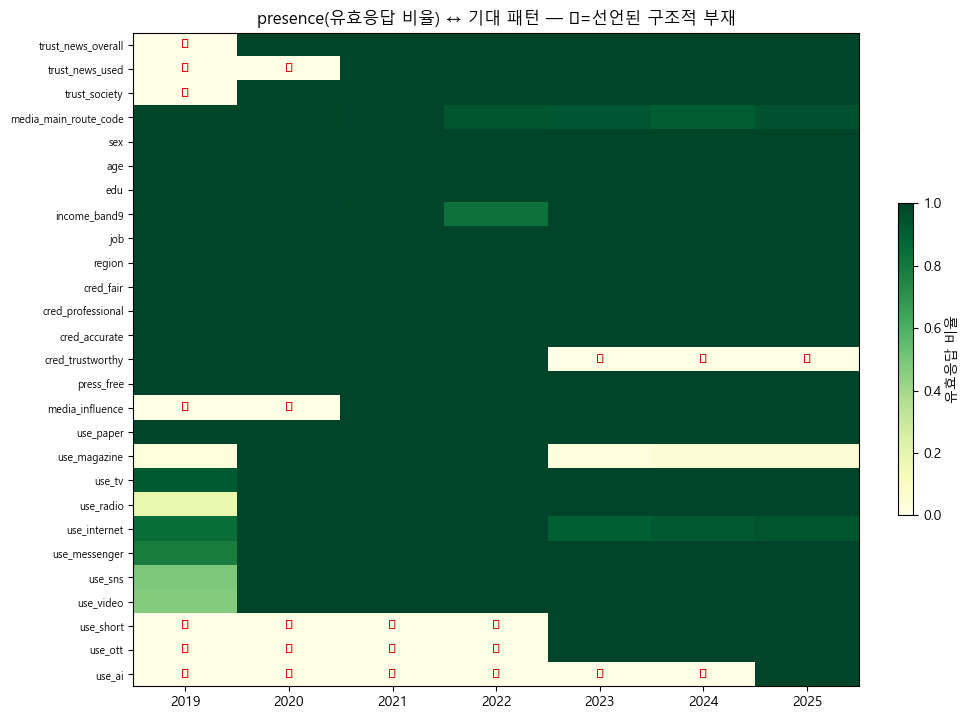

In [3]:
pm = hz.presence_matrix(panel)
# 라벨/밴드 target → 실측 컬럼 매핑: media_main_route는 코드 컬럼, income은 band9로 실측
COLMAP = {"media_main_route": "media_main_route_code", "income": "income_band9"}
# presence_matrix의 target 목록 밖 변수(신설매체)는 패널에서 직접 보충 실측
for extra in list(hz.USE_NEW_MEDIA):
    if extra not in pm.columns:
        pm[extra] = panel.groupby("year")[extra].count()

mismatches = []
for tgt, ymap in EXP.items():
    col = COLMAP.get(tgt, tgt)
    if col not in pm.columns:
        mismatches.append((tgt, "-", "presence 행렬에 컬럼 없음")); continue
    for y in hz.YEARS:
        n = int(pm.loc[y, col]); want = ymap[y]
        if want and n == 0:
            mismatches.append((tgt, y, "기대 존재인데 유효 0"))
        if (not want) and n > 0:
            mismatches.append((tgt, y, f"기대 부재인데 유효 {n:,}"))
print(f"대조 결과 — 불일치 {len(mismatches)}건")
for m in mismatches:
    print("  ✗", m)

# 히트맵(비율) + 기대 부재 ✕ 오버레이
cols = [COLMAP.get(t, t) for t in EXP if COLMAP.get(t, t) in pm.columns]
prop = pm[cols].div(pm["N"], axis=0)
fig, ax = plt.subplots(figsize=(9.8, max(4.5, 0.27 * len(cols))))
im = ax.imshow(prop.T.values, cmap="YlGn", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(prop.index))); ax.set_xticklabels(prop.index)
ax.set_yticks(range(len(cols))); ax.set_yticklabels(cols, fontsize=7.5)
tgt_of = {COLMAP.get(t, t): t for t in EXP}
for j, c in enumerate(cols):
    for i, y in enumerate(hz.YEARS):
        if not EXP[tgt_of[c]][y]:
            ax.text(i, j, "✕", ha="center", va="center", color="#c00", fontsize=9)
ax.set_title("presence(유효응답 비율) ↔ 기대 패턴 — ✕=선언된 구조적 부재")
fig.colorbar(im, ax=ax, fraction=0.02, label="유효응답 비율")
fig.tight_layout(); plt.show()

**관찰**: ✕가 놓인 자리(2019 신뢰 3종·2020 `trust_news_used`·2023+ `cred_trustworthy`·2019~2020 `media_influence`·신설매체의 초기 연도들)만 정확히 비어 있다 — crosswalk가 선언한 부재와 패널의 구멍이 **완전히 포개진다**. 이 포개짐이 "결측은 설계다"(`10` [발견 ⑤])의 기계 검증판이다.

## **4. [발견] 유효응답 규모 — 분석별 병목 지도**

같은 presence 행렬을 '규모' 관점으로 다시 읽는다: 각 분석 체인이 의존하는 변수군의 **최소 유효응답**이 그 분석의 실질 표본이다.

In [4]:
chains = {
    "MGCFA·정렬(21~23): cred 핵심3": ["cred_fair", "cred_professional", "cred_accurate"],
    "APC(24): cred3 + age": ["cred_fair", "cred_professional", "cred_accurate", "age"],
    "단일문항 삼각(17): trust_news_overall": ["trust_news_overall"],
    "NCHI(03): cred3 + richness": ["cred_fair", "cred_professional", "cred_accurate", "richness_fixed8"],
    "페르소나 프로파일(04·08): + 인구": ["cred_fair", "richness_fixed8", "age", "edu"],
}
rows = []
for name, cols in chains.items():
    mins = pm[cols].min(axis=1)
    rows.append({"분석 체인": name, "최소 유효(전 연도합)": int(mins.sum()),
                 "병목 연도": int(mins.idxmin()), "병목 유효 N": int(mins.min())})
pd.DataFrame(rows).set_index("분석 체인")

,최소 유효(전 연도합),병목 연도,병목 유효 N
분석 체인,,,
MGCFA·정렬(21~23): cred 핵심3,90996,2023,5000
APC(24): cred3 + age,90996,2023,5000
단일문항 삼각(17): trust_news_overall,85956,2019,0
NCHI(03): cred3 + richness,90996,2023,5000
페르소나 프로파일(04·08): + 인구,90996,2023,5000


**관찰**: cred 핵심3 기반 체인은 7개년 전부 두텁다(병목조차 수천 명). 단일문항 삼각(B궤적)만 2019가 0(구조적 부재)이라 **2020~2025 6개년**으로 정의된다 — `17`·`23` §4·`30` §3의 "B궤적은 6개년" 표기가 데이터 구조에서 강제된 것임을 확인한다.

## **5. [입증] 검증 셀 — 전 셀 assert**

In [5]:
# (a) 기대 ↔ 실측 전 셀 일치
assert len(mismatches) == 0, f"crosswalk 불일치 {len(mismatches)}건: {mismatches[:5]}"
n_cells = sum(1 for t in EXP for _ in hz.YEARS if COLMAP.get(t, t) in pm.columns)
print(f"(a) 기대 패턴 ↔ presence 전 셀 대조: {n_cells}셀 불일치 0건 PASS")

# (b) 핵심 구조 재확인 — 문서에 박힌 구조적 부재의 대표 4건
assert int(pm.loc[2019, "trust_news_overall"]) == 0
assert int(pm.loc[2020, "trust_news_used"]) == 0
assert all(int(pm.loc[y, "cred_trustworthy"]) == 0 for y in [2023, 2024, 2025])
assert all(int(pm.loc[y, c]) > 0 for y in hz.YEARS
           for c in ["cred_fair", "cred_professional", "cred_accurate"])
print("(b) 대표 구조 4건(2019 단일문항 부재 · 2020 used 부재 · trustworthy 2023+ 부재 · 핵심3 7개년 존재) PASS")

# (c) 파생 richness — 8매체가 전부 있으므로 7개년 전부 유효
assert all(int(pm.loc[y, "richness_fixed8"]) > 0 for y in hz.YEARS)
print("(c) richness_fixed8 7개년 유효 PASS")
print("\n검증 (a)~(c) 전부 PASS — crosswalk 게이트 폐쇄")

(a) 기대 패턴 ↔ presence 전 셀 대조: 189셀 불일치 0건 PASS
(b) 대표 구조 4건(2019 단일문항 부재 · 2020 used 부재 · trustworthy 2023+ 부재 · 핵심3 7개년 존재) PASS
(c) richness_fixed8 7개년 유효 PASS

검증 (a)~(c) 전부 PASS — crosswalk 게이트 폐쇄


## **6. 종합**

### **연구질문 답**

- **Q1** — 매핑 선언에서 도출한 기대 패턴과 패널 presence가 **전 셀 일치**(불일치 0건, §5 (a)). 오매핑 축은 `12`(공표치 대조)가, 가용성 축은 본 노트북이 맡아 crosswalk 오류의 두 형태가 모두 게이트로 닫혔다.
- **Q2** — 기대 부재 칸만 정확히 비어 있다(§3 히트맵의 ✕ 자리). 기대 밖 구멍 0건 — 구현 버그의 지문 없음.
- **Q3** — cred 핵심3 체인은 병목 연도조차 수천 명 규모로 두텁고, 단일문항 궤적만 2019 부재로 6개년이다(§4) — 각 분석의 표본 정의가 데이터 구조에서 나온다.

### **단계 요약**

| § | 한 일 | 판정 |
|---|------|:---:|
| 2 | 매핑 선언 → 기대 패턴 기계 도출 | 27종×7개년 |
| 3 | presence 실측 ↔ 기대 전 셀 대조 + [시각화] | 불일치 0 |
| 4 | 분석 체인별 병목 지도 | 표 확정 |
| 5 | 일괄 assert | **PASS** |

**다음**: `16`(2022 구조 심층) → `19`(품질 게이트 종합)로 1x 데이터 트랙을 닫는다. crosswalk 개정 시 이 노트북 재실행이 회귀 테스트다.